# Density of States Calculation

The **Density of States (DOS)** is a fundamental concept in condensed matter physics and materials science. It describes how many states are available within a specific energy range for particle to occupy. In essence, it quantifies the number of quantum states per unit energy interval at each energy level, giving insight into a material's electronic, optical, and thermal properties.

Mathematically, the DOS $D(E)$ is defined as:

$$
D(E) = \frac{dN}{dE}
$$

where $N(E)$ is the number of states with energy less than or equal to $E$.

Direct computation of the DOS involves diagonalizing the system’s Hamiltonian, which has a computational complexity of $\mathcal{O}(n^3)$, where $n$ is the system size. This becomes infeasible for large or complex systems, such as disordered materials or many-body interacting systems. To address this, we use the **Kernel Polynomial Method (KPM)** \[1], an efficient and scalable technique for estimating the DOS. KPM reduces the problem to a **trace estimation**, which scales as $\mathcal{O}(n)$ - $\mathcal{O}(n^3)$, making it highly suitable for large sparse Hamiltonians.

### The KPM Algorithm

The core idea of KPM is to approximate the DOS using a series expansion in **Chebyshev polynomials**, which are numerically stable and well-suited for functions defined on the interval $[-1, 1]$. The method proceeds in the following steps:

#### 1. **Rescale the Hamiltonian**

Since Chebyshev polynomials are defined on $[-1, 1]$, the Hamiltonian $H$ must be linearly rescaled so that all its eigenvalues fall within this interval:

$$
\tilde{H} = \frac{H - b}{a}
$$

where $a$ and $b$ are determined based on the spectral bounds (minimum and maximum eigenvalues) of $H$.

#### 2. **Expand DOS in Chebyshev Polynomials**

The DOS is approximated by a finite sum over Chebyshev polynomials $T_n(E)$:

$$
\rho(E) \approx \frac{1}{\pi \sqrt{1 - E^2}} \left[ \mu_0 + 2 \sum_{n=1}^{N-1} \mu_n T_n(E) \right]
$$

where $\mu_n$ are the **Chebyshev moments**, given by:

$$
\mu_n = \text{Tr}[T_n(\tilde{H})]
$$

These moments encode how each polynomial contributes to reconstructing the DOS.

#### 3. **Estimate the Trace Stochastically**

Instead of computing the trace exactly (which can be costly), we approximate it using a small number of random vectors $|r\rangle$:

$$
\mu_n \approx \frac{1}{R} \sum_{r=1}^{R} \langle r | T_n(\tilde{H}) | r \rangle
$$

Where R is the number of moment. This is known as **stochastic trace estimation** (typically sclaes as $\mathcal{O(n)}$), and it significantly reduces computational cost while maintaining accuracy for large matrices (as R is inversly proportional to the dimension of the Hamiltonian).

#### 4. **Apply a Smoothing Kernel**

To mitigate Gibbs oscillations caused by truncating the polynomial series, a smoothing kernel (such as the **Jackson kernel**) is applied to the coefficients:

$$
\mu_n \rightarrow g_n \mu_n
$$

where $g_n$ are kernel weights that damp high-frequency components, leading to a smoother and more physically accurate approximation of the DOS.

### Practical Usage with Kwant

To demonstrate KPM in practice, we will use the excellent Python library **[Kwant](https://kwant-project.org/)** \[2], which provides built-in functions for computing the DOS and related observables efficiently using methods like KPM.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from moirepy import BilayerMoireLattice, HexagonalLayer

In [5]:
lattice = BilayerMoireLattice(
    latticetype=HexagonalLayer,
    ll1=1, ll2=2,
    ul1=2, ul2=1,
    n1=10, n2=10, ## u need to reasonably large system for better convergence of DoS
    ## Dont worry as kpm is very efficient for large systems!!!
    pbc=False  
)

twist angle = 0.3803 rad (21.7868 deg)
1400 cells in upper lattice
1400 cells in lower lattice


In [6]:
#import kwant for calculations for DoS calculations
import kwant
#!pip install kwant

## Case 1: Study of DoS with random onsite disorder!

We will show the density of states (DoS) of the moiré system under random onsite potential. This study is very useful for understanding the effects of disorder on electronic properties, such as localization, gap filling, transport behavior in moiré materials and many more.

In [7]:
w = np.random.uniform(-1, 1)

In [8]:
lattice.generate_connections(inter_layer_radius=1)

real_ham = lattice.generate_hamiltonian(
    tll=1, tuu=1,
    tul=1, tlu=1,
    tuself=w, tlself=w
).toarray().real

the strength of the onside disorder is w: -0.04769177819134929


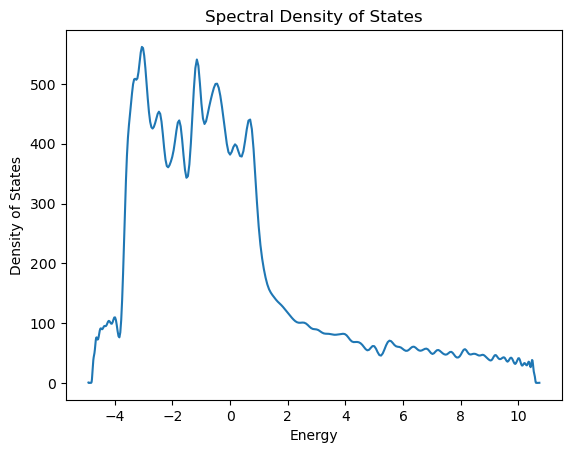

In [ ]:
## estimate the spectral density of states
x = kwant.kpm.SpectralDensity(real_ham, params=None, operator=None, num_vectors=20, num_moments=200)
# By dafault it choose Jacson Kernel.
print(f"the strength of the onside disorder is w: {w}")
e, rho = x()
plt.plot(e, rho)
plt.xlabel('Energy')
plt.ylabel('Density of States')
plt.title('Spectral Density of States')
plt.show()

## Case 2: Study of DoS under Gaussian hopping

In [15]:
## Define the Gaussian-decay inter-layer hopping function
def gaussian_inter(pos_i, pos_j, R, type_i, type_j, lattice, t0, rc):
    """Gaussian-decay inter-layer hopping."""
    # R maps pos_j to its true physical coordinate inside the supercell
    r = np.linalg.norm(pos_i - (pos_j + R), axis=1)  
    return t0 * np.exp(-(r / rc) ** 2) 

In [16]:
T0      =  0.5  # inter-layer amplitude at r=0
RC      =  1.0  # Gaussian decay length

ham = lattice.generate_hamiltonian(
    tll=1,           # float: same hop for every intra-lower bond
    tuu=1,           # float: same hop for every intra-upper bond
    tul=gaussian_inter,    # callable
    tlu=gaussian_inter,    # callable (tlu = tul dagger for a Hermitian system)
    tlself=0.0,            # float: zero on-site energy
    tuself=0.0,            # float: zero on-site energy
    extra_inputs={"t0": T0, "rc": RC},
).toarray()

In [17]:
def get_kpm_dos(rc):
    sys = lattice.generate_hamiltonian(
        tll=1, tuu=1,
        tul=gaussian_inter, tlu=gaussian_inter,
        extra_inputs={"t0": T0, "rc": rc},
    ).toarray()


    spectrum = kwant.kpm.SpectralDensity(sys, params=None, operator=None, num_vectors=20, num_moments=200) 
    ## adjust num_vectors and num_moments for better accuracy
    energies, densities = spectrum()

    return energies, densities

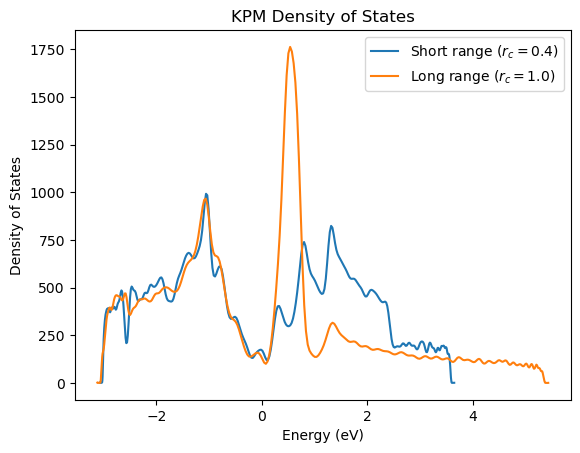

In [18]:
for rc, label in zip(
    [0.4, 1.0],
    [r"Short range ($r_c = 0.4$)", r"Long range ($r_c = 1.0$)"],
):
    energies, densities = get_kpm_dos(rc)
    plt.plot(energies, densities, label=label)

plt.xlabel("Energy (eV)")
plt.ylabel("Density of States")
plt.title("KPM Density of States")
plt.legend()
plt.show()

It is clear that for different `rc` values the layers coupled differently and the peak structure changes visibly. 

!!! note
    `generate_hamiltonian` runs in $O(N)$ time once connections are established. You can call it repeatedly with different `rc` or `t0` values without rebuilding the lattice or re-running `generate_connections`.

Also this exmaple illustrate that you can use `kwant` library to compute the physical observable and analyse the physics of moire system. 

## References
1. Alexander Weibe, Gerhard Wellein, Andreas Alvermann and Holger Fehske, The kernel polynomial method, Reviews of Modern Physics, Volume 78, January 2006
   
2. C. W. Groth, M. Wimmer, A. R. Akhmerov, X.Waintal, Kwant: a software package for quantum transport, New J. Phys. 16, 063065 (2014).